# Theta scaling analysis for MGD on LAGRANGIAN TURBULENCE data
Load data from an ensemble of experiments 

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from matplotlib.colors import to_rgb
from pathlib import Path
import sys
import copy
import math
from types import SimpleNamespace

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from utils import *
from utils_experiment import * 
from utils_entropy import *
from filters_bank import * 
from check_moments import *
from potentials import *
from filters import *
from ortho_wavelet import *
from check_potentials import *  # theta_column_map, find_matching_reference_potentials, etc. -- this module used to be named theta_analysis_v2.py, see cell below



sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [3]:
# Persistent across reruns, same pattern as `results`
if 'config_by_seed' not in locals() and 'config_by_seed' not in globals():
    config_by_seed = {}
if 'potentials_by_seed' not in locals() and 'potentials_by_seed' not in globals():
    potentials_by_seed = {}

def get_potentials_for_seed(key, M, base_args, root, device):
    """Lazily load+cache a seed's fitted potentials, reconstructing from disk
    if this session doesn't have them cached yet."""
    if key in potentials_by_seed:
        return potentials_by_seed[key]
    if key not in config_by_seed:
        raise KeyError(
            f"No resolved_config recorded for {key} — it was probably loaded into "
            f"`results` in an earlier session/cell before config_by_seed existed. "
            f"Re-run the loading loop (with config_by_seed populated) for this seed."
        )
    resolved_config = config_by_seed[key]
    potentials_k = load_potentials_for_config(
        resolved_config, M, J=base_args.J, Q=base_args.Q,
        terms=base_args.terms, root=root, device=device
    )
    potentials_by_seed[key] = potentials_k
    return potentials_k

def load_potentials_for_config(resolved_config, M, J, Q, terms, root, device):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)

    potentials = get_1d_potentials(
        terms, J, filters, Q,
        scalar_param=None, parallel=False,
        filters_Q=filters_Q, filters_Phi=filters_Phi,
    )

    potentials_dir = Path(root) / "experiments" / resolved_config / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(
            f"No fitted_potentials dir for {resolved_config} at {potentials_dir}"
        )

    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters   # whichever bank THIS potential actually got assigned
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded

    return potentials

def compute_phi_X(potentials, x1):
    evaluated_features = []
    for p in potentials.values():
        feat = p(x1)
        if feat.ndim == 1:
            feat = feat.unsqueeze(1)
        evaluated_features.append(feat)
    return torch.cat(evaluated_features, dim=-1)

In [4]:
# Default parameters
J = 8
Q = 3
M = 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 5e-07
n_subsample = 200
regularization = 1e-2

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

# LAGRANGIAN TURBULENCE DATA 
Data = load_turbulence_1d().to(device) 
print(Data.shape, Data.device) 
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])

print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800]) cuda:0
torch.Size([10000, 1, 1024])
x1 shape: torch.Size([5000, 1, 256])


In [5]:
terms=[
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK", 
]

filters = return_Filters(M, J, 1, device=device) 
potentials = get_1d_potentials(
    terms, J, filters, Q,
    scalar_param=None, parallel=False,
    )

base_args = SimpleNamespace(
    J=J,
    Q=Q,
    terms=terms, 
    nt=nt,
    sigma=sigma,
    interpolant='Cos',
    regularization=regularization,
    lam=lam,
    n_subsample=n_subsample,
    batch_size="", # Adjust based on your x1.shape[0] // 2
    label="",
    #timestamp="",    # Leave empty to allow the resolver to find the latest run
    n1=n1
)

In [6]:
experiments_to_compare = {
    f'seed{i}': {"seed": i} for i in range(1)
}

In [7]:
import gc
import torch
import os 
import re 


# Assuming `results` already exists or you want to start fresh:
if 'results' not in locals() and 'results' not in globals():
    results = {}

pattern = re.compile(
    r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_(\d+)_terms2f1130a8_20260728_1232$"
)

print("Scanning directory once...")
# 2. Grab all directory contents just once to avoid heavy repetitive disk lookups
all_folders = os.listdir(os.path.join(root, "saved_results/samples"))
# 1. Define the 4 separate chunk ranges
chunks = [
    range(300, 313),   # 0 to 12
    range(313, 325),  # 13 to 24
    range(325, 338),  # 25 to 37
    range(338, 350)   # 38 to 49
]

for chunk_idx, seed_range in enumerate(chunks, 1):
    print(f"=== PROCESSING CHUNK {chunk_idx}/4 (Seeds {seed_range.start} to {seed_range.stop - 1}) ===")

    current_chunk_runs = {}
    for folder in all_folders:
        match = pattern.match(folder)
        if match:
            seed_val = int(match.group(1))
            if seed_val in seed_range:
                current_chunk_runs[f"seed{seed_val}"] = folder

    KEYS_TO_KEEP = {'theta_t', 'Theta_reg', 't'}
    potentials_by_seed = {} 
    for key, resolved_config in sorted(current_chunk_runs.items(),
                                        key=lambda x: int(x[0].replace("seed", ""))):
        print(f"  [{key}] Loading: {resolved_config}")
        loaded_data = try_load_experiment(root, resolved_config, device)

        if loaded_data and loaded_data.get('loaded', False):
            filtered_data = {k: loaded_data[k] for k in KEYS_TO_KEEP if k in loaded_data}
    
            potentials_k = load_potentials_for_config(
                resolved_config, M, J=base_args.J, Q=base_args.Q,
                terms=base_args.terms, root=root, device=device
            )
            phi_X_k = compute_phi_X(potentials_k, x1)
            filtered_data['phi_X'] = phi_X_k
            filtered_data['num_potentials'] = phi_X_k.shape[-1]
    
            expected = filtered_data['theta_t'].shape[-1]
            if phi_X_k.shape[-1] != expected:
                print(f"    -> MISMATCH for {key}: skipping.")
                del loaded_data, potentials_k, phi_X_k
                continue
    
            results[key] = filtered_data
            config_by_seed[key] = resolved_config   # NEW — needed for lazy reload later
            potentials_by_seed[key] = potentials_k   # keep it — needed for compute_m1 later
            del loaded_data
        else:
            print(f"    -> Warning: Failed to read data for {key}")
    print(f"=== CHUNK {chunk_idx} FINISHED. Current results size: {len(results)} ===")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nAll chunks processed successfully! Total items in results: {len(results)}")

Scanning directory once...
=== PROCESSING CHUNK 1/4 (Seeds 300 to 312) ===
  [seed300] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232
  [seed301] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_301_terms2f1130a8_20260728_1232
  [seed302] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_302_terms2f1130a8_20260728_1232
  [seed303] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_303_terms2f1130a8_20260728_1232
  [seed304] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_304_terms2f1130a8_20260728_1232
  [seed305] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_305_terms2f1130a8_20260728_1232
  [seed306] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_306_terms2f1130a8_20260728_1232
  [seed307] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_307_t

In [8]:
# ------------------------------------------------------------------
# Extract final-time feature vectors for Theta_reg and theta_MGD per seed
# Shape assumed: (time, features) -> take [-1, :] to get all features at final time
# ------------------------------------------------------------------
final_theta_reg = {}   # seed_int -> tensor/array of shape (features,)
final_theta_MGD = {}   # seed_int -> tensor/array of shape (features,)

for key, data in results.items():
    seed_val = int(key.replace("seed", ""))

    if 'Theta_reg' not in data:
        print(f"  [WARNING] {key}: no Theta_reg found, skipping")
        continue
    if 'theta_t' not in data:
        print(f"  [WARNING] {key}: no theta_t found, skipping")
        continue

    theta_reg = data['Theta_reg']
    theta_MGD = data['theta_t']

    # Move to CPU tensors if needed
    if torch.is_tensor(theta_reg):
        theta_reg = theta_reg.detach().cpu()
    if torch.is_tensor(theta_MGD):
        theta_MGD = theta_MGD.detach().cpu()

    # (time, features) -> take last time step, keep all features
    final_reg_vals = theta_reg[-1, :]
    final_mgd_vals = theta_MGD[-1, :]

    final_theta_reg[seed_val] = final_reg_vals
    final_theta_MGD[seed_val] = final_mgd_vals

seeds_sorted = sorted(final_theta_reg.keys())
n_features_reg = len(final_theta_reg[seeds_sorted[0]]) if seeds_sorted else 0
n_features_mgd = len(final_theta_MGD[seeds_sorted[0]]) if seeds_sorted else 0

print(f"\nCollected final-time feature vectors for {len(seeds_sorted)} seeds: "
      f"Theta_reg has {n_features_reg} features, theta_MGD has {n_features_mgd} features.")

final_theta_MGD[seed_val].shape

# Convert dictionaries of 1D vectors into 2D tensors of shape (n_seeds, n_features)
reg_all = torch.stack([final_theta_reg[s] for s in seeds_sorted])
mgd_all = torch.stack([final_theta_MGD[s] for s in seeds_sorted])

print(f"Aggregated {len(seeds_sorted)} seeds into matrices of shape {reg_all.shape}.")


Collected final-time feature vectors for 50 seeds: Theta_reg has 272 features, theta_MGD has 272 features.
Aggregated 50 seeds into matrices of shape torch.Size([50, 272]).


In [9]:
seed_keys = sorted(results.keys(), key=lambda k: int(k.replace("seed", "")))
theta_t_list = [results[k]['theta_t'].to(device) for k in seed_keys]
theta_reg_t_list = [results[k]['Theta_reg'].to(device) for k in seed_keys]
phi_X_list   = [results[k]['phi_X'].to(device) for k in seed_keys]

## Histograms of the per-family energy components

Turbulence analogue of `theta_interpretation/theta_interpretation_analysis.ipynb`
section 5 (per-component energy histograms + total log p_theta(x)).

In the 1D toy Gaussian notebook, every term is scalar (`x2`, `x4`, ...), so
the "energy component" `theta_k * phi_k(x)` -- one summand of
`theta^T phi(x)`, the quantity that actually enters the fitted
log-density -- is already a single number per sample. Here each potential
*family* (`L_6`, `L_6_psi`, `Scattering_Fourth_Order_Mod2_Real_Q1`, ...) is
itself a whole block of coefficients, not one number, so the direct analogue
is the family's own dot product with its theta block:

`energy_family(x) = theta_family . phi_family(x) = sum_{k in family} theta_k * phi_k(x)`

This collapses each family -- regardless of how many coefficients it has --
down to one scalar per sample, so families of very different dimensionality
become directly comparable, and the family energies sum exactly to the
(unnormalized) total log-density `theta^T phi(x)`.

Evaluated on the real turbulence data `x1` (not samples drawn from the
fitted density, unlike the 1D notebook): sampling from a fitted
high-dimensional MGD needs a full SDE integration, which is a cluster job
here, not a notebook cell (see `CLAUDE.md`). Uses `Theta_reg[-1]` (the
regularized final theta) for one representative seed, matching the 1D
notebook's choice of `Theta_reg[-1]` throughout its section 5.

In [10]:
# ------------------------------------------------------------
# Per-family energy components theta_family . phi_family(x1), one scalar
# per real-data sample per family. Uses a single representative seed's
# fitted potentials + Theta_reg[-1] (own column layout, so no dependence
# on potential_ranges/potential_colors built later in the notebook from a
# pooled reference potential).
#
# Family column ranges come from theta_column_map() (codes/check_potentials.py),
# the same shared helper reused later in the notebook (cells 25/28/32/39) via
# find_matching_reference_potentials/build_all_averaged_vectors, instead of a
# second hand-rolled cumulative-sum loop -- it also validates
# sum(dims) == n_theta and raises a detailed per-potential diagnostic if a
# fitted potential was pruned to an unexpected width.
# ------------------------------------------------------------

ENERGY_SEED = seed_keys[0]
print(f"Using {ENERGY_SEED} ({config_by_seed[ENERGY_SEED]}) as the representative fit.")

potentials_energy = get_potentials_for_seed(ENERGY_SEED, M, base_args, root, device)
phi_X_energy = results[ENERGY_SEED]['phi_X'].detach().cpu()          # (n1, n_features), real data
theta_energy = results[ENERGY_SEED]['Theta_reg'][-1].detach().cpu()  # regularized final theta

col_map_energy = theta_column_map(potentials_energy, theta_energy.shape[-1])
family_ranges = {name: (start, start + dim) for name, (start, dim) in col_map_energy.items()}

# Double-check against the naive cumulative-sum-of-num_coefficients construction
# (same potentials.items() order) -- should agree exactly whenever no per-seed
# pruning has happened. theta_column_map is kept as the source of truth going
# forward since it also validates the total against n_theta.
_naive_ranges, _start = {}, 0
for name, p in potentials_energy.items():
    _dim = p.num_coefficients
    _naive_ranges[name] = (_start, _start + _dim)
    _start += _dim
assert family_ranges == _naive_ranges, (
    f"theta_column_map disagrees with the naive num_coefficients loop:\n"
    f"  theta_column_map: {family_ranges}\n  naive loop:       {_naive_ranges}"
)

assert phi_X_energy.shape[-1] == theta_energy.shape[-1], (
    f"phi_X feature dim ({phi_X_energy.shape[-1]}) doesn't match theta feature dim "
    f"({theta_energy.shape[-1]}) -- {ENERGY_SEED}'s fitted potentials don't match "
    f"its own saved theta/phi_X."
)

family_energy = {}   # name -> (n1,) array, theta_family . phi_family(x) per sample
for name, (a, b) in family_ranges.items():
    family_energy[name] = (theta_energy[a:b] * phi_X_energy[:, a:b]).sum(dim=-1).numpy()

total_log_p_unnorm = np.sum(np.stack(list(family_energy.values())), axis=0)  # theta^T phi(x), no log Z

print(f"\n{'family':45s} {'dim':>5s} {'mean':>12s} {'std':>12s}")
for name, (a, b) in family_ranges.items():
    comp = family_energy[name]
    print(f"{name:45s} {b-a:5d} {comp.mean():12.4g} {comp.std(ddof=1):12.4g}")


Using seed300 (turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232) as the representative fit.

family                                          dim         mean          std
L_6                                               9       -1.974        19.65
L_6_psi                                          25        3.646        16.74
L_2_lowpass                                       1        13.34        18.92
Scalar_psi_gaussianK                             70         1324        514.5
Scalar_morlet_gaussianK                          27       -457.6        194.2
Scattering_Fourth_Order_Mod2_Real_Q1             84        -11.3        52.75
Scattering_Fourth_Order_Mod2_Imag_Q1             56       0.1447        7.849


In [11]:
%matplotlib inline 

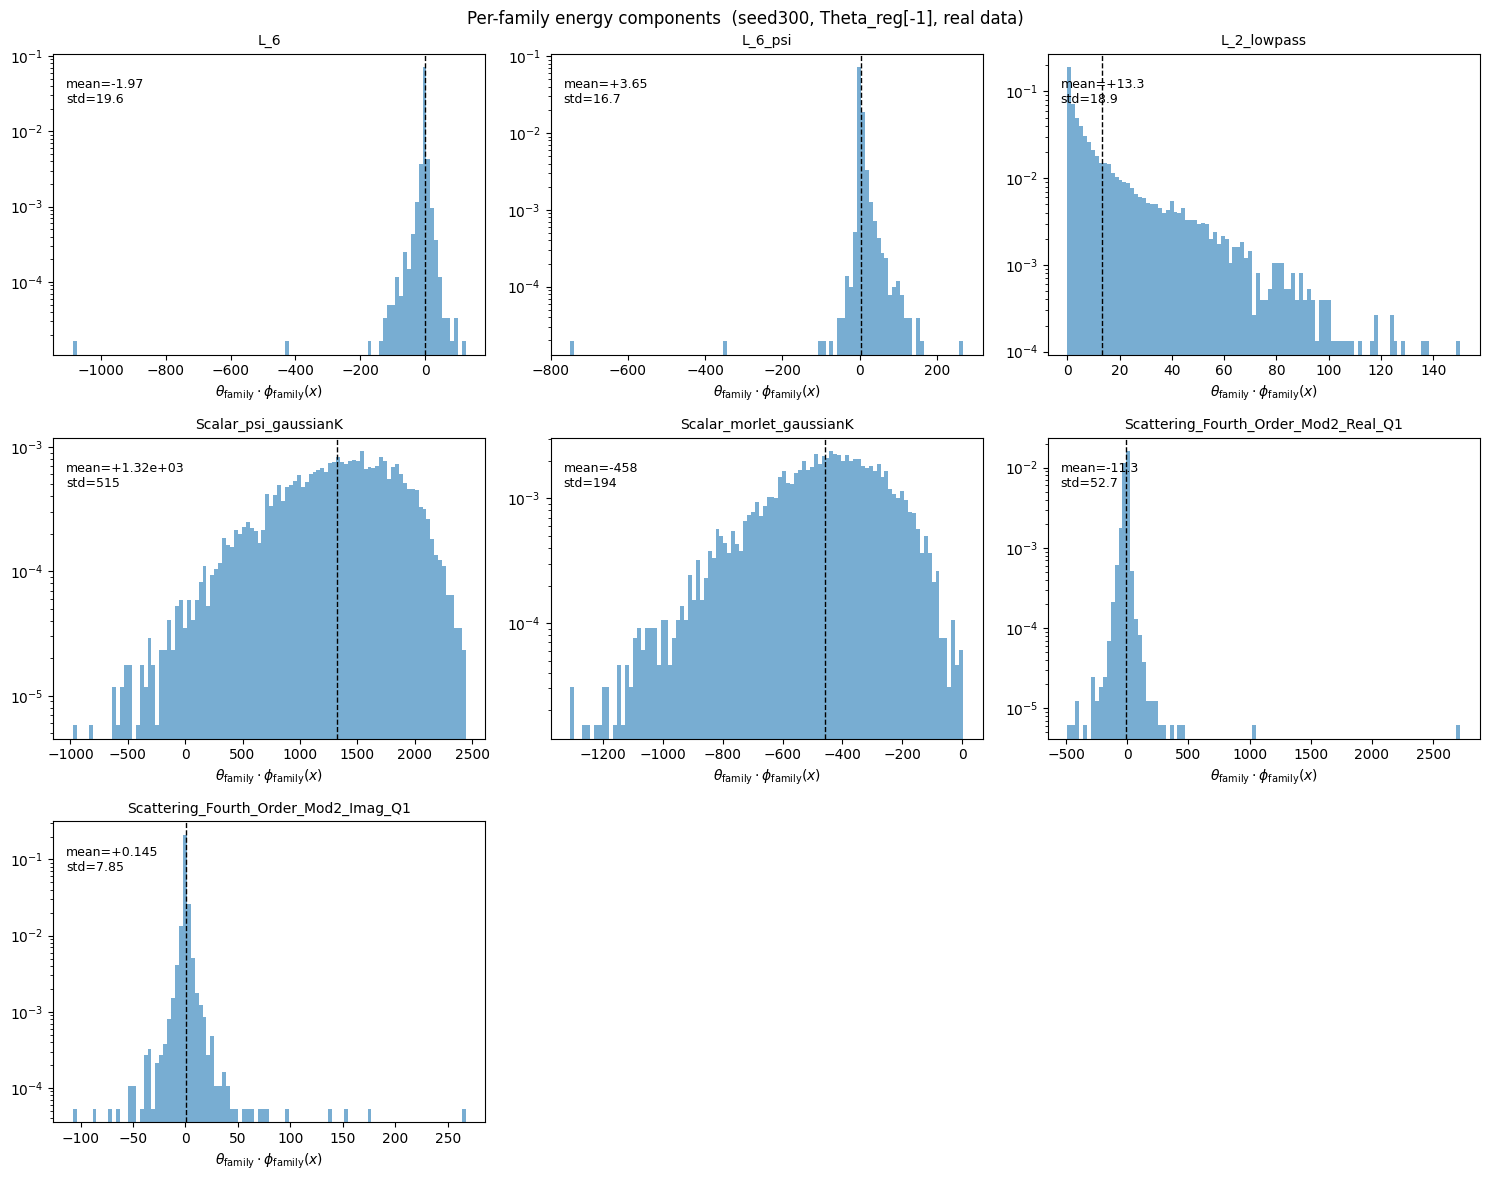

In [12]:
# ------------------------------------------------------------
# One histogram per family: theta_family . phi_family(x), across the n1
# real-data samples. Log y-scale, same convention as the 1D notebook's
# energy-component histograms, since the tails are the informative part.
# ------------------------------------------------------------

n_families = len(family_energy)
n_cols = 3
n_rows = math.ceil(n_families / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, (name, comp) in enumerate(family_energy.items()):
    ax = axes[i // n_cols][i % n_cols]
    mean, std = comp.mean(), comp.std(ddof=1)
    ax.hist(comp, bins=100, density=True, alpha=0.6)
    ax.axvline(mean, color='k', ls='--', lw=1)
    ax.text(0.03, 0.92, f"mean={mean:+.3g}\nstd={std:.3g}",
            transform=ax.transAxes, fontsize=9, va='top')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(r'$\theta_{\mathrm{family}} \cdot \phi_{\mathrm{family}}(x)$')
    ax.set_yscale('log')

for j in range(n_families, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')

fig.suptitle(f"Per-family energy components  ({ENERGY_SEED}, Theta_reg[-1], real data)")
fig.tight_layout()
plt.show()

,family,dim,mean,std,var
0,Scalar_psi_gaussianK,70,1324.068848,514.533875,264745.093750
1,Scalar_morlet_gaussianK,27,-457.556702,194.151871,37694.949219
2,Scattering_Fourth_Order_Mod2_Real_Q1,84,-11.303513,52.749096,2782.467285
3,L_6,9,-1.974127,19.649544,386.104553
4,L_2_lowpass,1,13.335847,18.921013,358.004761
5,L_6_psi,25,3.646330,16.738760,280.186096
6,Scattering_Fourth_Order_Mod2_Imag_Q1,56,0.144672,7.848684,61.601845


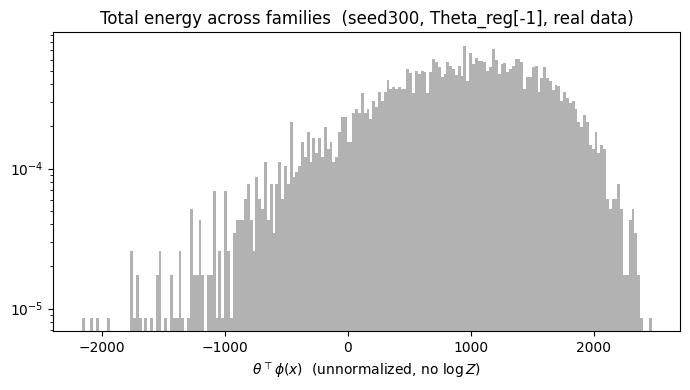

theta^T phi(x): mean=+870.4  std=708.9


In [13]:
# ------------------------------------------------------------
# Summary table, sorted by variance -- which families' energy
# fluctuations dominate the total, i.e. which terms actually move
# theta^T phi(x) from sample to sample. Plus the total unnormalized
# log-density histogram (sum of all family energies), the turbulence
# analogue of the 1D notebook's log p_theta(x) histogram (section 5.2) --
# no log Z term since there's no cheap quadrature/bound normalizer wired
# up for this multi-family, high-dimensional case yet.
# ------------------------------------------------------------

energy_summary = pd.DataFrame([
    {
        'family': name,
        'dim': b - a,
        'mean': family_energy[name].mean(),
        'std': family_energy[name].std(ddof=1),
        'var': family_energy[name].var(ddof=1),
    }
    for name, (a, b) in family_ranges.items()
]).sort_values('var', ascending=False).reset_index(drop=True)
display(energy_summary)

plt.figure(figsize=(7, 4))
plt.hist(total_log_p_unnorm, bins=200, density=True, alpha=0.6, color='tab:gray')
plt.yscale('log')
plt.xlabel(r'$\theta^\top \phi(x)$  (unnormalized, no $\log Z$)')
plt.title(f'Total energy across families  ({ENERGY_SEED}, Theta_reg[-1], real data)')
plt.tight_layout()
plt.show()

print(f"theta^T phi(x): mean={total_log_p_unnorm.mean():+.4g}  "
      f"std={total_log_p_unnorm.std(ddof=1):.4g}")

## Per-coefficient energy components (not summed within family)

Same `theta_energy` / `phi_X_energy` as the per-family energies above, but without the within-family `.sum(dim=-1)` -- one energy value `theta_k * phi_k(x)` per individual coefficient `k`, plotted across the full feature index with the family boundaries shaded in the background (same convention as `potential_colors` in the theta-scaling section below).

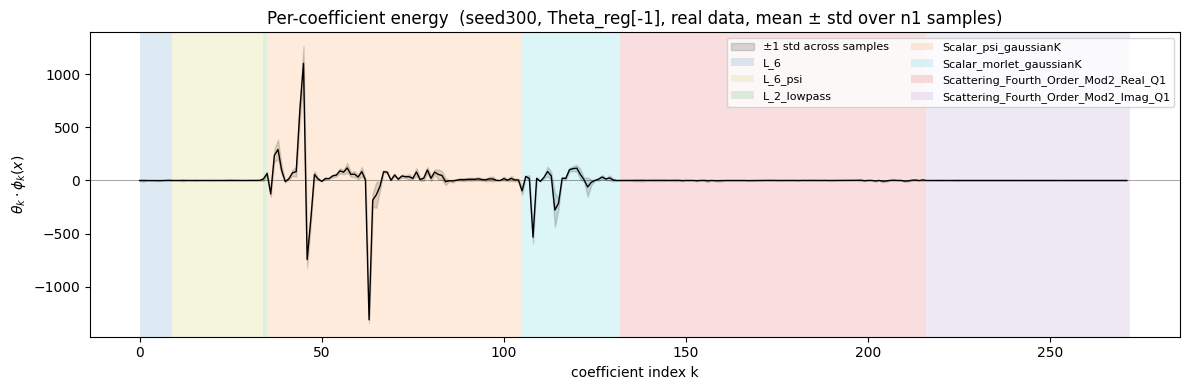

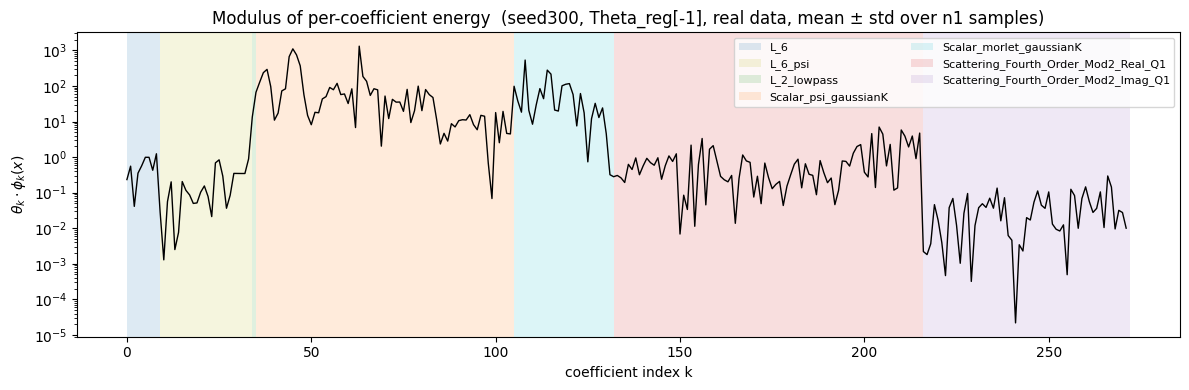

In [23]:
# ------------------------------------------------------------
# Per-single-theta_k energy: theta_k * phi_k(x), NOT summed within family --
# same theta_energy / phi_X_energy as the per-family plot above, just without
# the family_energy[...] = (...).sum(dim=-1) reduction. Shaded with the same
# family-boundary color convention used later in the notebook (potential_colors,
# cell 38), duplicated here so this cell doesn't depend on a cell defined
# further down the notebook.
# ------------------------------------------------------------

energy_percoef = (theta_energy[None, :] * phi_X_energy).numpy()  # (n1, n_features)
percoef_mean = energy_percoef.mean(axis=0)
percoef_std = energy_percoef.std(axis=0, ddof=1)

_base_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive",
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan",
}
_fallback_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
family_colors = {
    name: _base_colors.get(name, _fallback_cycle[i % len(_fallback_cycle)])
    for i, name in enumerate(family_ranges.keys())
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(len(percoef_mean))
ax.plot(k, percoef_mean, color='black', lw=1)
ax.fill_between(k, percoef_mean - percoef_std, percoef_mean + percoef_std,
                 color='black', alpha=0.15, label='±1 std across samples')

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.15, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy  ({ENERGY_SEED}, Theta_reg[-1], real data, mean ± std over n1 samples)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

# modulus energy, log scale 
fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(len(percoef_mean))
ax.plot(k, np.abs(percoef_mean), color='black', lw=1)

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.15, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Modulus of per-coefficient energy  ({ENERGY_SEED}, Theta_reg[-1], real data, mean ± std over n1 samples)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_yscale("log") 
fig.tight_layout()
plt.show()


## Rare vs typical events: per-coefficient energy from `selected_samples.pt`

Loads `turbulence/selected_samples.pt` (built by `extract_samples.ipynb`, pulled from Jean Zay -- it isn't produced by anything that runs locally) -- a hand-picked `{"typical": [...], "rare": [...]}` set of raw turbulence snippets. Evaluates the same `ENERGY_SEED` fitted potentials (`potentials_energy`, `theta_energy` from the per-family energy section above) on each sample via `compute_phi_X` (cell 5), giving `theta_k * phi_k(x)` per coefficient per sample -- same family-shaded x-axis as the per-coefficient plot above, but one curve per individual real sample instead of a mean over `x1`.

In [28]:
samples_path = root / "selected_samples.pt"
if not samples_path.exists():
    raise FileNotFoundError(
        f"{samples_path} not found -- pull it from Jean Zay first, e.g.:\n"
        f"  rsync -avP <jean_zay_host>:/lustre/fswork/projects/rech/wbg/ukv59en/"
        f"MGD-for-Maximum-Entropy-Generation/turbulence/selected_samples.pt {samples_path}"
    )

samples = torch.load(samples_path, map_location=device)
print({cat: (len(v), v[0].shape, v[0].dtype) for cat, v in samples.items()})


{'typical': (8, torch.Size([1, 256]), torch.float32), 'rare': (8, torch.Size([1, 256]), torch.float32)}


In [29]:
# Stack each category into a batch and evaluate the SAME representative
# seed's fitted potentials used above (potentials_energy / theta_energy from
# the per-family energy section) -- so coefficient ordering/count matches
# theta_energy automatically, via the notebook's own compute_phi_X (cell 5).
sample_energy = {}   # category -> (n_samples_in_category, n_features)
for category, tensors in samples.items():
    x_cat = torch.stack([t.to(device) for t in tensors], dim=0)
    if x_cat.ndim == 2:            # (n, L) -> (n, 1, L) if the channel dim got squeezed out
        x_cat = x_cat.unsqueeze(1)
    phi_cat = compute_phi_X(potentials_energy, x_cat).detach().cpu()
    assert phi_cat.shape[-1] == theta_energy.shape[-1], (
        f"'{category}': phi_X has {phi_cat.shape[-1]} features, theta_energy has "
        f"{theta_energy.shape[-1]} -- selected_samples.pt's preprocessing doesn't "
        f"match {ENERGY_SEED}'s fitted potentials."
    )
    sample_energy[category] = (theta_energy[None, :] * phi_cat).numpy()
    print(f"{category}: {sample_energy[category].shape[0]} samples")

typical: 8 samples
rare: 8 samples


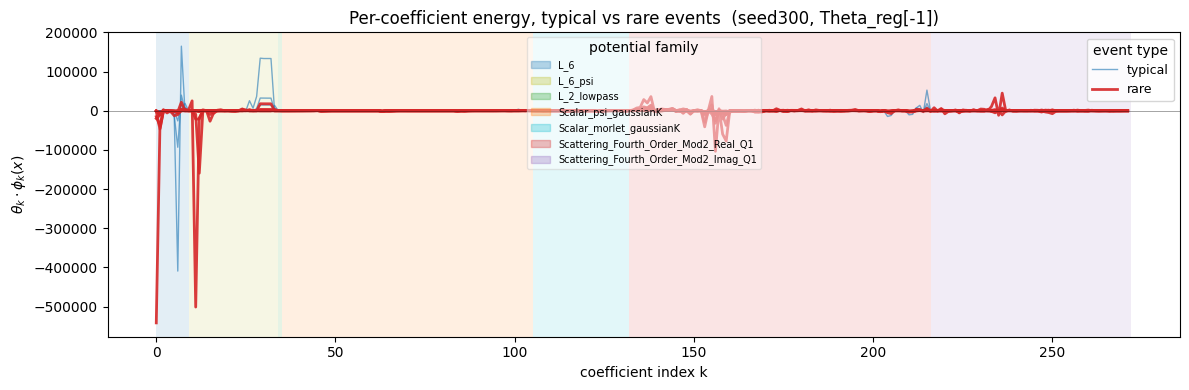

In [30]:
category_style = {
    "typical": dict(color="tab:blue", lw=1.0, alpha=0.6),
    "rare":    dict(color="tab:red",  lw=2.0, alpha=0.9),
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(theta_energy.shape[-1])

for category, energy in sample_energy.items():
    style = category_style.get(category, dict(lw=1.0, alpha=0.7))
    for i, curve in enumerate(energy):
        ax.plot(k, curve, label=category if i == 0 else None, **style)

# Two separate legends: one for typical/rare (line style), one for potential
# family (background color) -- built as proxy patches from family_colors
# rather than axvspan's own `label=`, so it doesn't get pulled into the
# typical/rare legend above.
category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(category_handles, category_labels, loc='upper right',
                             fontsize=9, title='event type')
ax.add_artist(category_legend)

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.12, lw=0)

family_handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[name], alpha=0.3)
                   for name in family_ranges]
ax.legend(family_handles, list(family_ranges.keys()), loc='upper center',
          fontsize=7, title='potential family', framealpha=0.5)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy, typical vs rare events  ({ENERGY_SEED}, Theta_reg[-1])')
fig.tight_layout()
plt.show()


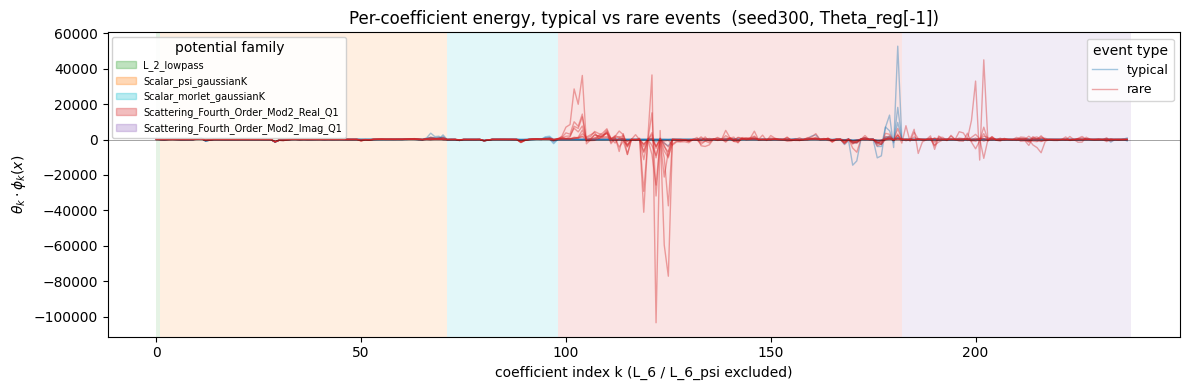

In [36]:
EXCLUDED_FAMILIES = {"L_6", "L_6_psi"}

# Build a contiguous k-axis over the kept families only (not the full
# n_features range with holes for the excluded ones) -- same cumulative-
# offset idea as family_ranges itself, restricted to the families we keep.
kept_families = [name for name in family_ranges if name not in EXCLUDED_FAMILIES]
keep_mask = np.zeros(theta_energy.shape[-1], dtype=bool)
for name in kept_families:
    a, b = family_ranges[name]
    keep_mask[a:b] = True

family_ranges_plot = {}
start = 0
for name in kept_families:
    a, b = family_ranges[name]
    dim = b - a
    family_ranges_plot[name] = (start, start + dim)
    start += dim

category_style = {
    "typical": dict(color="tab:blue", lw=1.0, alpha=0.4),
    "rare":    dict(color="tab:red",  lw=1.0, alpha=0.4),
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(keep_mask.sum())

for category, energy in sample_energy.items():
    style = category_style.get(category, dict(lw=1.0, alpha=0.2))
    for i, curve in enumerate(energy):
        ax.plot(k, curve[keep_mask], label=category if i == 0 else None, **style)

category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(category_handles, category_labels, loc='upper right',
                             fontsize=9, title='event type')
ax.add_artist(category_legend)

for name, (a, b) in family_ranges_plot.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.12, lw=0)

family_handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[name], alpha=0.3)
                   for name in kept_families]
ax.legend(family_handles, kept_families, loc='upper left',
          fontsize=7, title='potential family', framealpha=0.9)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k (L_6 / L_6_psi excluded)')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy, typical vs rare events  ({ENERGY_SEED}, Theta_reg[-1])')
fig.tight_layout()
plt.show()

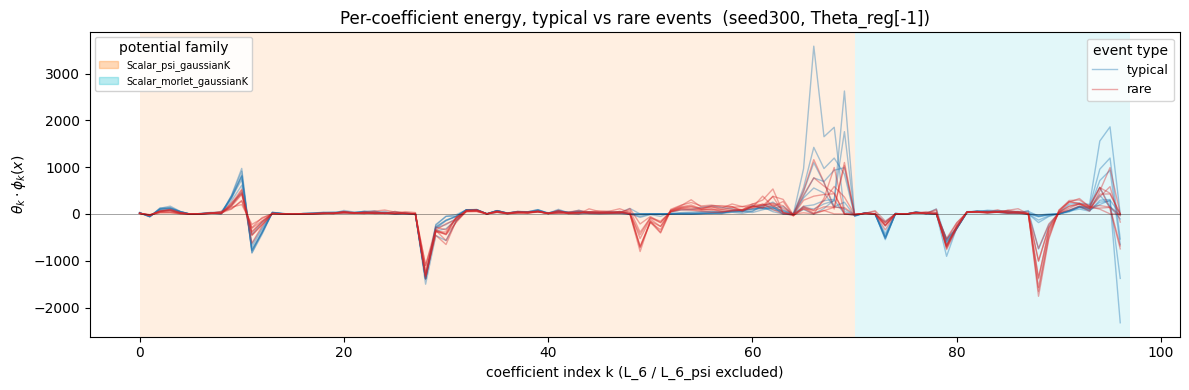

In [42]:
EXCLUDED_FAMILIES = {"L_2_lowpass", "L_6", "L_6_psi", 
                     "Scattering_Fourth_Order_Mod2_Real_Q1", "Scattering_Fourth_Order_Mod2_Imag_Q1"}

# Build a contiguous k-axis over the kept families only (not the full
# n_features range with holes for the excluded ones) -- same cumulative-
# offset idea as family_ranges itself, restricted to the families we keep.
kept_families = [name for name in family_ranges if name not in EXCLUDED_FAMILIES]
keep_mask = np.zeros(theta_energy.shape[-1], dtype=bool)
for name in kept_families:
    a, b = family_ranges[name]
    keep_mask[a:b] = True

family_ranges_plot = {}
start = 0
for name in kept_families:
    a, b = family_ranges[name]
    dim = b - a
    family_ranges_plot[name] = (start, start + dim)
    start += dim

category_style = {
    "typical": dict(color="tab:blue", lw=1.0, alpha=0.4),
    "rare":    dict(color="tab:red",  lw=1.0, alpha=0.4),
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(keep_mask.sum())

for category, energy in sample_energy.items():
    style = category_style.get(category, dict(lw=1.0, alpha=0.2))
    for i, curve in enumerate(energy):
        ax.plot(k, curve[keep_mask], label=category if i == 0 else None, **style)

category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(category_handles, category_labels, loc='upper right',
                             fontsize=9, title='event type')
ax.add_artist(category_legend)

for name, (a, b) in family_ranges_plot.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.12, lw=0)

family_handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[name], alpha=0.3)
                   for name in kept_families]
ax.legend(family_handles, kept_families, loc='upper left',
          fontsize=7, title='potential family', framealpha=0.9)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k (L_6 / L_6_psi excluded)')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy, typical vs rare events  ({ENERGY_SEED}, Theta_reg[-1])')
fig.tight_layout()
plt.show()

## Real vs. remapped-imaginary scattering energy, per trajectory

Compares `theta_k * phi_k(x)` for `Scattering_Fourth_Order_Mod2_Real_Q1` against
the same quantity for `Scattering_Fourth_Order_Mod2_Imag_Q1`, remapped onto the
real branch's coefficient layout via `expand_imag_to_real_indices` (same index
matching used elsewhere in this notebook for this potential pair, `index_convention='mod2'`).
One color per individual `selected_samples.pt` trajectory, shared with the raw
signal panel below it, so a given curve's source is identifiable.

In [40]:
REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"

pot_re = potentials_energy[REAL_KEY]
pot_im = potentials_energy[IMAG_KEY]
a_re, b_re = family_ranges[REAL_KEY]
a_im, b_im = family_ranges[IMAG_KEY]

scatter_energy = {}   # category -> {'real': (n, dim_re), 'imag_remapped': (n, dim_re)}
for category, energy in sample_energy.items():
    energy_real = energy[:, a_re:b_re]           # (n, dim_re), real branch's own layout
    energy_imag_own = energy[:, a_im:b_im]        # (n, dim_im), imaginary branch's own layout
    energy_imag_remapped = expand_imag_to_real_indices(
        pot_im, pot_re, energy_imag_own, index_convention='mod2',
    )                                              # (n, dim_re), zero-padded onto real's layout
    scatter_energy[category] = dict(real=energy_real, imag_remapped=energy_imag_remapped)
    print(f"{category}: real {energy_real.shape}, imag remapped {energy_imag_remapped.shape}")

typical: real (8, 84), imag remapped (8, 84)
rare: real (8, 84), imag remapped (8, 84)


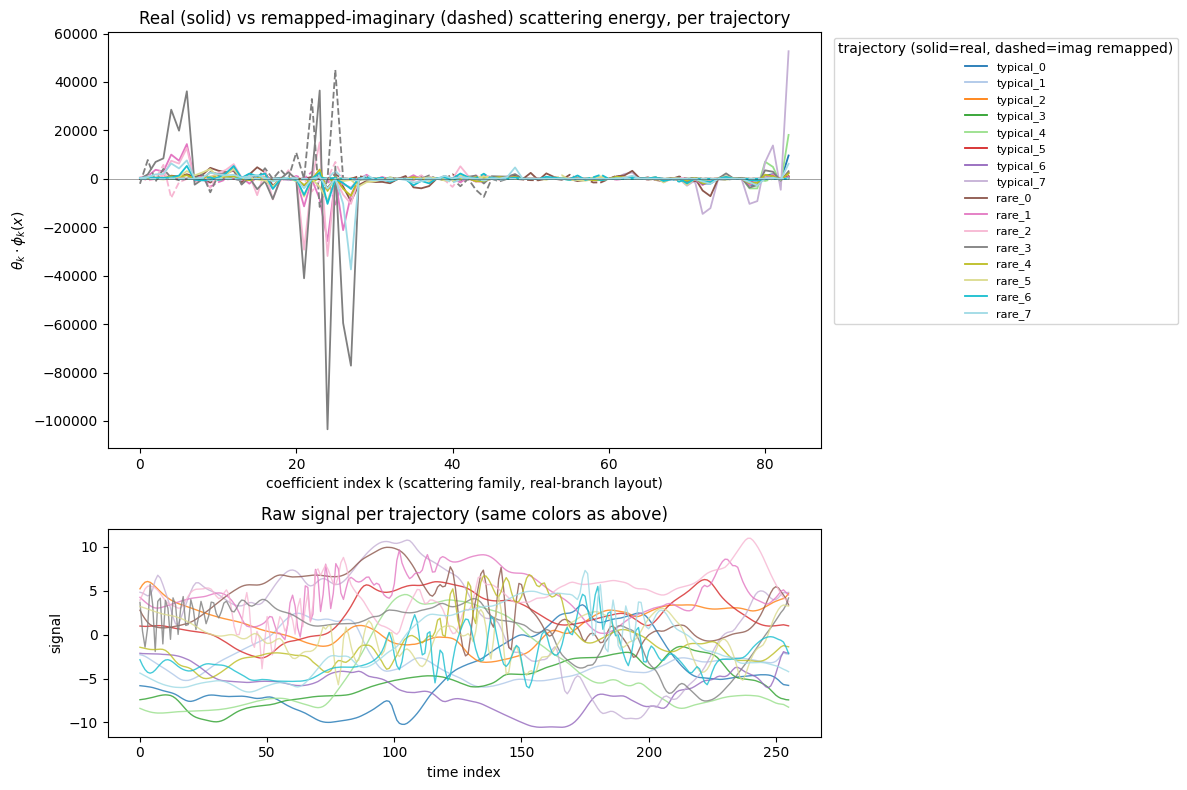

In [39]:

# One color per individual trajectory, shared between the energy comparison
# above and the raw-signal panel below, so a curve's color identifies exactly
# which selected_samples.pt entry it came from. Labeled positionally
# (category_index) -- add_sample()/save_samples() aren't in the repo, so
# there's no guarantee of the original Data index being recoverable.
trajectory_labels, trajectory_signals = [], []
for category, tensors in samples.items():
    for i, t in enumerate(tensors):
        trajectory_labels.append(f"{category}_{i}")
        trajectory_signals.append((category, i, t))

n_traj = len(trajectory_labels)
cmap = plt.get_cmap('tab20', n_traj)   # up to 20 distinct colors; repeats/blends beyond that
trajectory_colors = {label: cmap(i) for i, label in enumerate(trajectory_labels)}

k_scatter = np.arange(b_re - a_re)

fig, (ax_energy, ax_signal) = plt.subplots(
    2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]}
)

for category, energies in scatter_energy.items():
    for i in range(energies['real'].shape[0]):
        label = f"{category}_{i}"
        color = trajectory_colors[label]
        ax_energy.plot(k_scatter, energies['real'][i], color=color, lw=1.3,
                        ls='-', label=label)
        ax_energy.plot(k_scatter, energies['imag_remapped'][i], color=color, lw=1.3,
                        ls='--')

ax_energy.axhline(0, color='black', lw=0.5, alpha=0.5)
ax_energy.set_xlabel('coefficient index k (scattering family, real-branch layout)')
ax_energy.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax_energy.set_title('Real (solid) vs remapped-imaginary (dashed) scattering energy, per trajectory')
ax_energy.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8,
                  title='trajectory (solid=real, dashed=imag remapped)')

for category, i, t in trajectory_signals:
    label = f"{category}_{i}"
    signal = t[0].cpu().numpy() if t.ndim > 1 else t.cpu().numpy()
    ax_signal.plot(signal, color=trajectory_colors[label], lw=1.0, alpha=0.8)

ax_signal.set_xlabel('time index')
ax_signal.set_ylabel('signal')
ax_signal.set_title('Raw signal per trajectory (same colors as above)')

fig.tight_layout()
plt.show()

## Theta scaling analysis 

### Theta scaling plots 

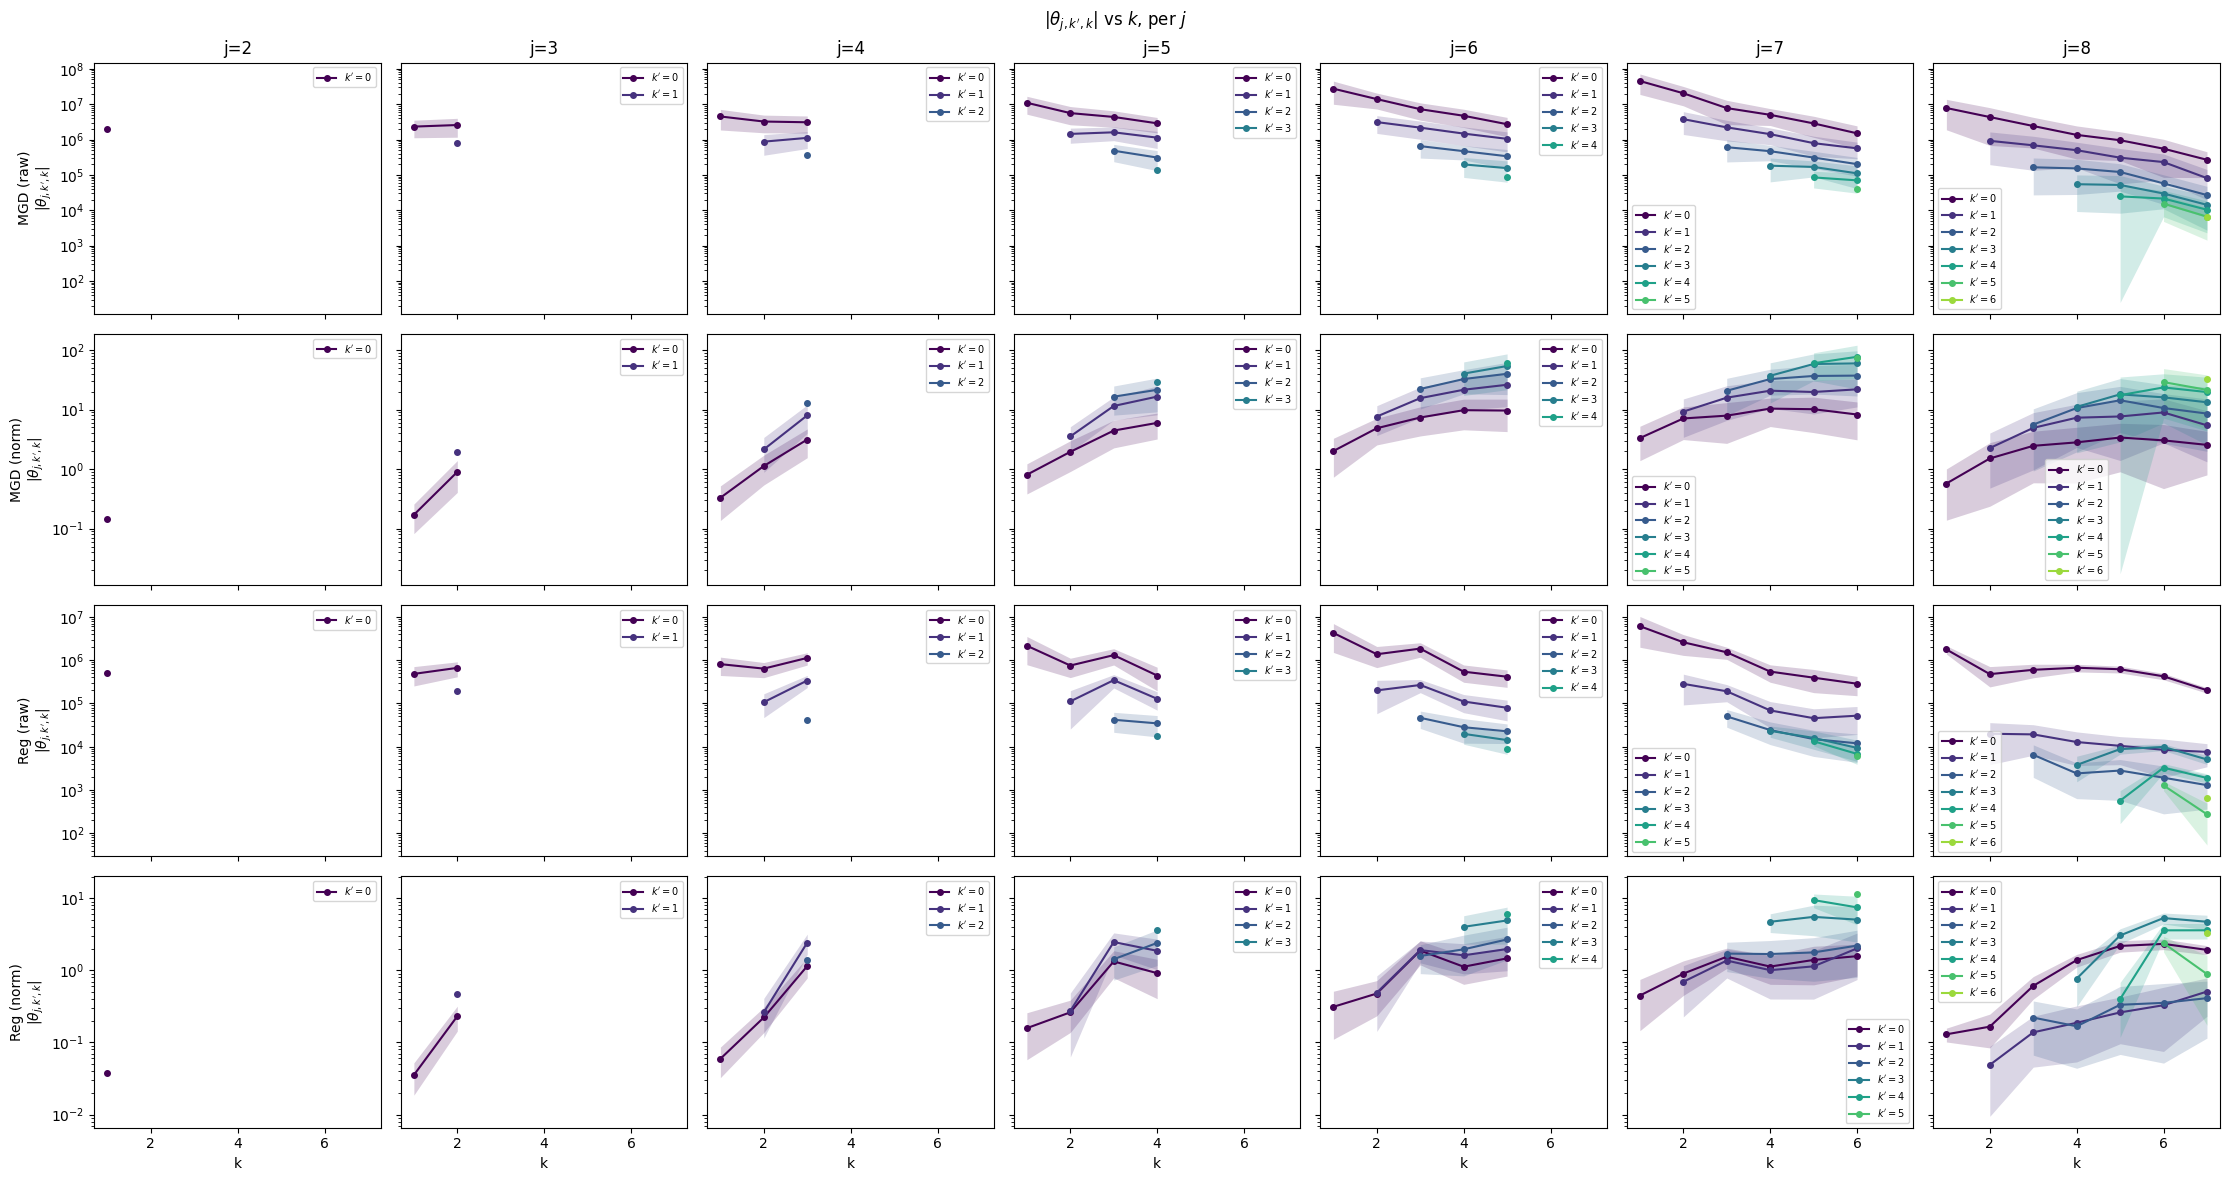

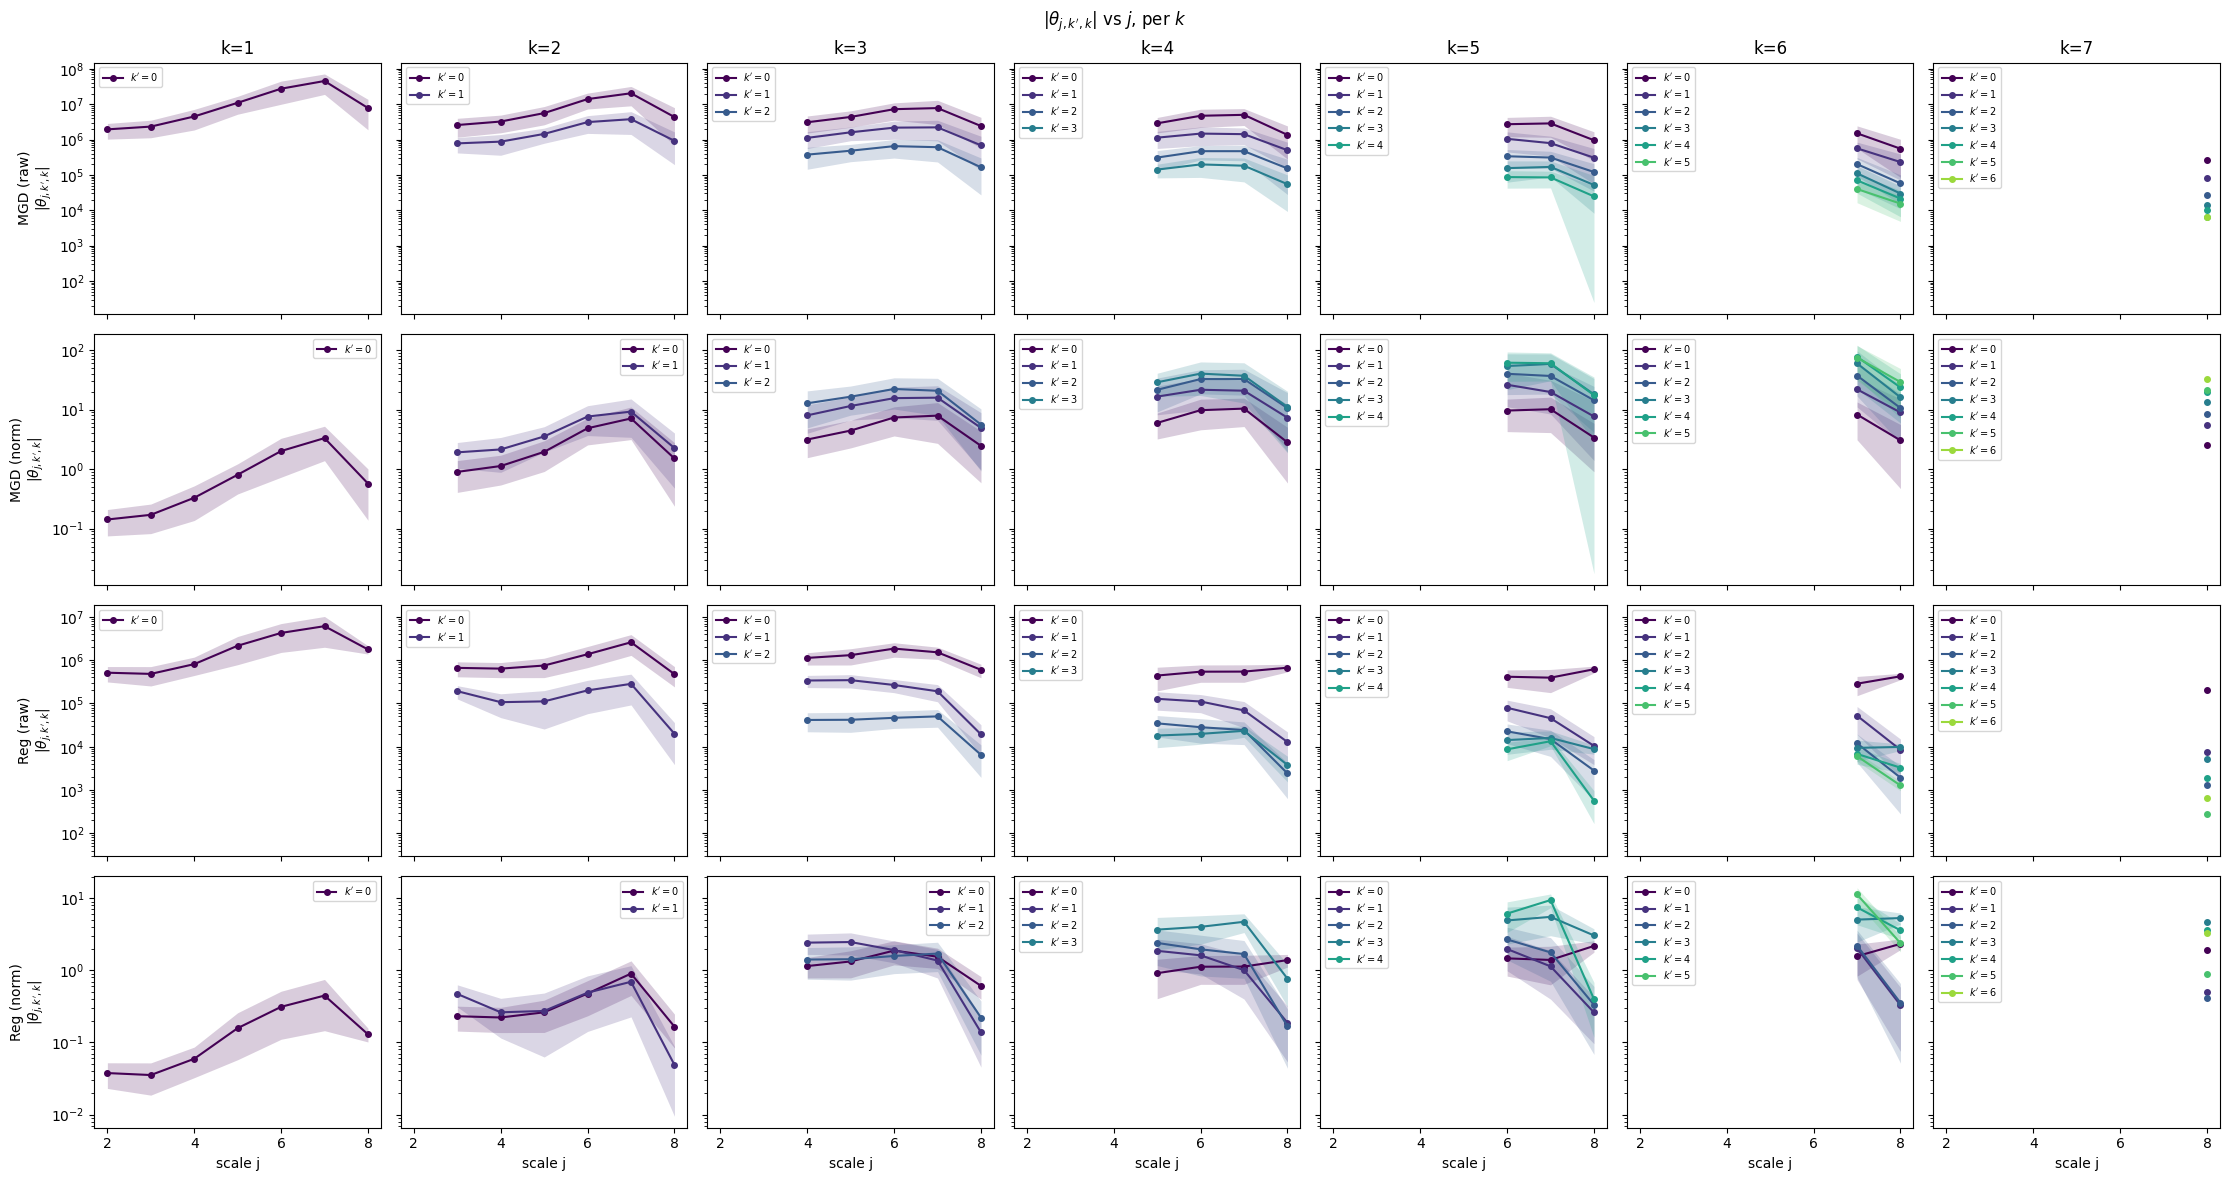

In [18]:
# Replaces the bottom section of the notebook (from
# "Build per-seed dataframes for theta_MGD and theta_reg..." onward).
# Everything above (results loading, reg_all/mgd_all, potential_ranges,
# terms, base_args, root, device, x1, filters) is unchanged. `filters` here
# is the notebook's J+1-channel single-layer filter bank
# (filters = return_Filters(M, J, 1, device=device)) -- it's only used as a
# fallback inside compute_norm_jab if a potential doesn't carry its own
# `.filters` attribute; in practice every potential you've fitted does, so
# pot_re.filters is what actually gets used.

# NOTE: compute_mk, build_theta_dataframe, build_complex_theta_dataframe,
# build_agg_cases, plot_modulus_vs_k_grid, plot_modulus_vs_j_grid,
# build_all_averaged_vectors, find_matching_reference_potentials etc. now come
# from `from check_potentials import *` in cell 1 -- this module used to be
# named theta_analysis_v2.py (see its docstring), which is why that import
# target no longer existed and this cell was left as a non-executed raw cell.

REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"
COMPLEX_NAME = "Scattering_Fourth_Order_Mod2_Q1"

# ------------------------------------------------------------
# 1. Per-seed complex dataframes for the Real+i*Imag scattering coefficient
# ------------------------------------------------------------
dfs = {}              # MGD
dfs_reg = {}           # Reg
potentials_by_seed = {}  # keep each seed's FITTED potentials -- needed below,
                          # since their pruned layout is what actually matches
                          # theta_t on disk, not the nominal get_1d_potentials(...)
mk_by_seed = {}        # matching m_k vector for each seed's fitted potentials
                        # (kept as an optional fallback normalization for
                        # potentials without scattering .indices; the Mod2
                        # pair itself now normalizes via compute_norm_jab)

for key in sorted(results.keys(), key=lambda s: int(s.replace("seed", ""))):
    potentials_k = get_potentials_for_seed(key, M, base_args, root, device)
    potentials_by_seed[key] = potentials_k
    m_k = compute_mk(potentials_k, x1)
    mk_by_seed[key] = m_k

    theta_final = results[key]["theta_t"][-1]
    dfs[key] = build_complex_theta_dataframe(
        theta_final, potentials_k, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
        # norm_order left as None -> auto-inferred to 4 since 'Mod2' is in REAL_KEY
    )

    theta_reg_final = results[key]["Theta_reg"][-1]
    dfs_reg[key] = build_complex_theta_dataframe(
        theta_reg_final, potentials_k, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
    )

# ------------------------------------------------------------
# 2. |theta_complex| vs k (per j) and vs j (per k), MGD vs Reg, raw + normalized
# ------------------------------------------------------------
cases = {
    'MGD (raw)':  {'dfs': dfs,     'value_col': 'theta_complex'},
    'MGD (norm)': {'dfs': dfs,     'value_col': 'theta_complex_normalized'},
    'Reg (raw)':  {'dfs': dfs_reg, 'value_col': 'theta_complex'},
    'Reg (norm)': {'dfs': dfs_reg, 'value_col': 'theta_complex_normalized'},
}
agg_cases = build_agg_cases(cases)

%matplotlib inline 
plot_modulus_vs_k_grid(agg_cases)   # |theta_complex| vs k, one panel per j
plot_modulus_vs_j_grid(agg_cases)   # |theta_complex| vs j, one panel per k

### Compare $\theta_k m_k$ interacting and not-interacting energy components 

In [19]:
non_scattering_names = [k for k in mgd_vectors.keys() if k != COMPLEX_NAME]

plot_theta_by_potential(mgd_vectors, potential_names=non_scattering_names,
                         title='MGD -- non-scattering potentials')
plot_theta_by_potential(reg_vectors, potential_names=non_scattering_names,
                         title='Reg -- non-scattering potentials')

plot_theta_by_potential(mgd_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                         title='MGD -- scattering potential (flat)')
plot_theta_by_potential(reg_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                         title='Reg -- scattering potential (flat)')

<class 'NameError'>: name 'mgd_vectors' is not defined

In [ ]:
ref_seed_reg, ref_potentials_reg, _ = find_matching_reference_potentials(reg_all, potentials_by_seed)
%matplotlib inline 
plot_linear_potential_mean_std(reg_all, ref_potentials_reg, 'L_6', terms, sign=-1)
plot_linear_potential_mean_std(reg_all, ref_potentials_reg, 'L_6_psi', terms, sign=-1)

## Sum of L6 psi and L6 terms 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_linear_potential_SUM_mean_std(theta_all, potentials,
                                       target_keys=('L_6', 'L_6_psi'),
                                       label=None, sign=1, known_dims=None,
                                       color='tab:orange', yscale='symlog',
                                       capsize=3):
    """
    Mean and propagated 1 std error bars for the SUM of two potentials.
    
    Explicitly uses error propagation (quadrature sum):
    1. Computes mean & std across seeds independently for both potentials.
    2. Groups 3 consecutive terms in key2 (3*J) via quadrature sum for stds:
       std_grouped = sqrt(std_a^2 + std_b^2 + std_c^2).
    3. Combines key1 and grouped key2 via quadrature sum:
       std_total = sqrt(std_key1^2 + std_grouped^2).
    """
    theta_np = theta_all.detach().cpu().numpy() if torch.is_tensor(theta_all) else np.asarray(theta_all)
    n_features = theta_np.shape[-1]
    
    col_map = theta_column_map(potentials, n_features, known_dims=known_dims, verbose=False)
    
    for key in target_keys:
        if key not in col_map:
            raise KeyError(f"'{key}' not found in potentials: {list(potentials.keys())}")
            
    key1, key2 = target_keys
    start1, dim1 = col_map[key1]
    start2, dim2 = col_map[key2]
    
    slice1 = theta_np[:, start1:start1+dim1]      # (nseed, J+1)
    slice2 = theta_np[:, start2:start2+dim2]      # (nseed, 3J+1)
    
    J = dim1 - 1
    
    # aggregate psi within each seed
    psi = slice2[:, :3*J].reshape(-1, J, 3).sum(axis=-1)
    
    # append the constant
    psi = np.concatenate(
        [psi, slice2[:, -1][:, None]],
        axis=1
    )
    
    # total theta for each seed
    theta_total = sign * (slice1 + psi)
    print(theta_total > 0 ) 
    
    # now statistics
    final_mean = theta_total.mean(axis=0)
    final_std = theta_total.std(axis=0)
    
    for i, (m, s) in enumerate(zip(final_mean, final_std)):
        if m > 0:
            z = m / s if s > 0 else np.inf
            print(f"{i:2d}: mean={m:.4g}, std={s:.4g}, z={z:.2f}")
    
    # Plotting
    x = np.arange(dim1)
    default_name = f"{key1} + {key2} (propagated error)"
    label = label or f"{default_name}{' (negated)' if sign == -1 else ''} (mean)"
    
    plt.figure(figsize=(max(6, dim1 * 0.3), 4))
    plt.errorbar(
        x, final_mean, yerr=final_std, fmt='-o', color=color, label=label,
        capsize=capsize, elinewidth=1.2, capthick=1.2
    )
    
    if yscale != 'linear':
        plt.yscale(yscale)
        
    plt.title(f'{default_name} (mean +- 1 std propagated)')
    plt.xlabel('coefficient index (J + 1)')
    plt.ylabel('theta sum')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    if (final_mean < 0).any() and yscale == 'log':
        print(f"WARNING: {default_name} has negative values but yscale='log' -- "
              f"those points are invisible on the plot above. Use 'symlog' or 'linear'.")
        
plot_linear_potential_SUM_mean_std(reg_all, ref_potentials_reg) 

In [ ]:
list(reference_potentials.keys())

In [ ]:
# ------------------------------------------------------------
# Compute theta column ranges for each potential
# ------------------------------------------------------------
for name, X in {"Theta_reg": theta_reg, "Theta_MGD": theta_mgd}.items():
    mean = X.mean(axis=0)
    # ddof=1 per varianza/std campionaria corretta
    std = X.std(axis=0, ddof=1)
    var = std**2
    cv = std / (np.abs(mean) + eps)
    rel_var = var / (mean**2 + eps)
    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(
        mean=mean, std=std, var=var, cv=cv, rel_var=rel_var, snr=snr
    )
# ------------------------------------------------------------
# 2. Correzione Loop Feature (Scatter plot anziché line plot)
# ------------------------------------------------------------
# Plot solo dei primi 4 parametri a titolo di esempio (evitiamo di bloccare il notebook)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    # Centriamo rispetto alla media delle seed
    mgd_centered = theta_mgd[:, i] - stats["Theta_MGD"]["mean"][i]
    reg_centered = theta_reg[:, i] - stats["Theta_reg"]["mean"][i]
    
    seeds_idx = np.arange(n_seeds)
    ax.scatter(seeds_idx, mgd_centered, label="MGD", color="tab:blue", alpha=0.7)
    ax.scatter(seeds_idx, reg_centered, label="REG", color="tab:orange", alpha=0.7)
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"Feature Index {i} (Centered across seeds)")
    ax.set_xlabel("Seed Index")
    ax.set_ylabel("Deviazione dalla media")
    ax.legend()
plt.tight_layout()
plt.show()

potential_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive", 
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan", 
}


In [ ]:
import pandas as pd

# ------------------------------------------------------------
# Use the currently loaded runs directly — no file load.
# reg_all / mgd_all were built earlier from `results` via
# torch.stack([final_theta_reg[s] for s in seeds_sorted]) etc.
# ------------------------------------------------------------
seeds = seeds_sorted

theta_reg = reg_all.detach().cpu().numpy()
theta_mgd = mgd_all.detach().cpu().numpy()

print("Theta_reg shape :", theta_reg.shape)
print("Theta_MGD shape :", theta_mgd.shape)

n_seeds, n_features = theta_reg.shape
assert n_features == n_features_reg == n_features_mgd, (
    "reg_all/mgd_all feature dim doesn't match n_features_reg/n_features_mgd "
    "computed earlier — check seeds_sorted and results are in sync."
)

%matplotlib inline
eps = 1e-12

stats = {}

for name, X in {
    "Theta_reg": theta_reg,
    "Theta_MGD": theta_mgd,
}.items():
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    var = std**2
    cv = std / (np.abs(mean) + eps)
    rel_var = var / (mean**2 + eps)
    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(mean=mean, std=std, var=var, cv=cv, rel_var=rel_var, snr=snr)

summary = pd.DataFrame({
    "Theta_reg mean variance": [stats["Theta_reg"]["var"].mean()],
    "Theta_MGD mean variance": [stats["Theta_MGD"]["var"].mean()],
    "Theta_reg median variance": [np.median(stats["Theta_reg"]["var"])],
    "Theta_MGD median variance": [np.median(stats["Theta_MGD"]["var"])],
    "Theta_reg mean CV": [stats["Theta_reg"]["cv"].mean()],
    "Theta_MGD mean CV": [stats["Theta_MGD"]["cv"].mean()],
    "Theta_reg mean SNR": [stats["Theta_reg"]["snr"].mean()],
    "Theta_MGD mean SNR": [stats["Theta_MGD"]["snr"].mean()],
})
display(summary)

corrs = np.array([
    np.corrcoef(theta_reg[:, j], theta_mgd[:, j])[0, 1]
    for j in range(n_features)
])
print("Mean correlation :", np.nanmean(corrs))
print("Median correlation :", np.nanmedian(corrs))

# ------------------------------------------------------------
# potential_ranges from the live reference potentials, via theta_column_map()
# (codes/check_potentials.py) -- single source of truth, same helper used for
# cell 18's family_ranges, instead of two independently hand-rolled loops
# that could silently diverge. Iterated in potential_colors' order so legend
# order matches the color dict below.
# ------------------------------------------------------------
reference_seed_name, reference_potentials, _ = find_matching_reference_potentials(
    reg_all, potentials_by_seed
)

col_map = theta_column_map(reference_potentials, n_features_reg)

missing_colors = [name for name in col_map if name not in potential_colors]
if missing_colors:
    raise KeyError(
        f"No entry in potential_colors for: {missing_colors} — "
        f"add colors for these or they won't be shaded in the plots."
    )

potential_ranges = {
    name: (col_map[name][0], col_map[name][0] + col_map[name][1])
    for name in potential_colors.keys() if name in col_map
}

total_from_potentials = max(b for _, b in potential_ranges.values())
assert total_from_potentials == n_features_reg == n_features_mgd, (
    f"Potential-range total ({total_from_potentials}) doesn't match the actual "
    f"feature dimension from disk (theta_reg={n_features_reg}, theta_MGD={n_features_mgd}). "
    f"This means {reference_seed_name}'s pruning differs from the pooled theta arrays — "
    f"check that all seeds in `seeds_sorted` were fit with the same active regions."
)
print(potential_ranges)

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Variance across seeds")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["rel_var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["rel_var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Relative variance")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.plot(stats["Theta_reg"]["snr"], label="Theta_reg")
plt.plot(stats["Theta_MGD"]["snr"], label="Theta_MGD")
plt.yscale("log") 
plt.xlabel("Feature")
plt.ylabel("Signal / Noise")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))

plt.loglog(
    stats["Theta_reg"]["var"],
    stats["Theta_MGD"]["var"],
    "."
)

xmin = min(
    stats["Theta_reg"]["var"].min(),
    stats["Theta_MGD"]["var"].min()
)
xmax = max(
    stats["Theta_reg"]["var"].max(),
    stats["Theta_MGD"]["var"].max()
)

plt.plot([xmin,xmax],[xmin,xmax],"k--")

plt.xlabel("Variance Theta_reg")
plt.ylabel("Variance Theta_MGD")
plt.tight_layout()
plt.show()

idx = np.argsort(stats["Theta_reg"]["var"])[::-1]

print("Largest Theta_reg variances")
for i in idx[:10]:
    print(i, stats["Theta_reg"]["var"][i])

print()

idx = np.argsort(stats["Theta_MGD"]["var"])[::-1]

print("Largest Theta_MGD variances")
for i in idx[:10]:
    print(i, stats["Theta_MGD"]["var"][i])